
# Bitcoin Market Sentiment vs. Hyperliquid Trader Performance
### An Analysis of the Fear & Greed Index and On-Chain Perpetuals Trading Behavior

**Author:** *Ananya Verma*
**Role:** Data Science Intern Candidate
**Date:** *4 july 2026*

---

## 1. Project Overview

The objective of this project is to analyze whether Bitcoin market sentiment, represented by the Fear & Greed Index, influences trader performance on the Hyperliquid platform.

Using historical trading data and daily sentiment values, I cleaned and merged both datasets on the trading date, performed exploratory data analysis, and compared trader behavior across different market conditions.

The analysis focuses on profitability, win rate, leverage usage, trade size, trading direction, and statistical relationships between market sentiment and trading performance.

## 2. Import Libraries

In [1]:

# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Statistics ---
from scipy import stats

# --- Utilities ---
import os
import warnings
warnings.filterwarnings("ignore")

# --- Global plotting style (consistent, presentation-ready look) ---
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"Fear": "#E74C3C", "Greed": "#27AE60", "Neutral": "#95A5A6"}
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load Datasets


In [6]:

FEAR_GREED_PATH = r'C:\Users\gofor\Downloads\fear_greed_index.csv'
HYPERLIQUID_PATH = r'C:\Users\gofor\Downloads\historical_data.csv'

CANDIDATE_DIRS = [".", "/content", "/content/drive/MyDrive", "/mnt/user-data/uploads"]

def locate_file(filename):
    for d in CANDIDATE_DIRS:
        candidate = os.path.join(d, filename)
        if os.path.exists(candidate):
            return candidate
    return None

fg_path = locate_file(FEAR_GREED_PATH)
hl_path = locate_file(HYPERLIQUID_PATH)

USE_SAMPLE_DATA = (fg_path is None) or (hl_path is None)

if USE_SAMPLE_DATA:
    print("⚠️  Real data files not found in the expected locations.")
    print("    -> Generating a SYNTHETIC sample dataset so the notebook can run end-to-end.")
    print("    -> Replace with the real CSVs and re-run for actual results.")
else:
    print(f"Found Fear & Greed file at: {fg_path}")
    print(f"Found Hyperliquid file at:  {hl_path}")


Found Fear & Greed file at: C:\Users\gofor\Downloads\fear_greed_index.csv
Found Hyperliquid file at:  C:\Users\gofor\Downloads\historical_data.csv


In [8]:

def generate_synthetic_data(n_days=420, n_traders=60, seed=42):
    '''Generates a realistic, schema-matching synthetic dataset for demo purposes only.'''
    rng = np.random.default_rng(seed)

    # ---- Synthetic Fear & Greed Index ----
    dates = pd.date_range("2024-01-01", periods=n_days, freq="D")
    # Mean-reverting random walk between 0-100
    fg_value = [50]
    for _ in range(n_days - 1):
        step = rng.normal(0, 6) - 0.03 * (fg_value[-1] - 50)
        fg_value.append(float(np.clip(fg_value[-1] + step, 5, 95)))
    fg_value = np.array(fg_value).round(0)

    def classify(v):
        if v <= 24:
            return "Extreme Fear"
        elif v <= 44:
            return "Fear"
        elif v <= 55:
            return "Neutral"
        elif v <= 75:
            return "Greed"
        else:
            return "Extreme Greed"

    fg_df = pd.DataFrame({
        "timestamp": (dates.astype(np.int64) // 10**9),
        "value": fg_value.astype(int),
        "value_classification": [classify(v) for v in fg_value],
        "date": dates.strftime("%d-%m-%Y"),
    })

    # ---- Synthetic Hyperliquid trades ----
    coins = ["BTC", "ETH", "SOL", "ARB", "DOGE", "AVAX", "MATIC", "LINK"]
    accounts = [f"0x{rng.integers(10**9,99**9):x}" for _ in range(n_traders)]

    n_trades = 25000
    trade_dates = rng.choice(dates, size=n_trades)
    sentiment_lookup = dict(zip(fg_df["date"].apply(lambda d: pd.to_datetime(d, format="%d-%m-%Y")), fg_value))

    rows = []
    for i in range(n_trades):
        d = pd.Timestamp(trade_dates[i])
        sent_val = sentiment_lookup.get(d, 50)
        # behavior tilts: higher leverage & long-bias in greed, more shorts & smaller size in fear
        greed_bias = (sent_val - 50) / 50  # -1..1
        side = "BUY" if rng.random() < (0.5 + 0.15 * greed_bias) else "SELL"
        coin = rng.choice(coins, p=[0.30,0.22,0.14,0.10,0.08,0.06,0.05,0.05])
        price = {"BTC": 60000, "ETH": 3000, "SOL": 140, "ARB": 1.1,
                 "DOGE": 0.15, "AVAX": 35, "MATIC": 0.8, "LINK": 15}[coin] * (1 + rng.normal(0, 0.05))
        leverage = max(1, rng.normal(8 + 4 * greed_bias, 4))
        size_tokens = abs(rng.normal(1, 0.8)) * (500 / price)
        size_usd = size_tokens * price
        fee = size_usd * 0.0004
        # PnL: slight edge for longs in greedy periods, shorts in fearful periods, plus noise
        directional_edge = greed_bias * (1 if side == "BUY" else -1) * 0.01
        pnl_pct = rng.normal(directional_edge, 0.04)
        closed_pnl = size_usd * pnl_pct - fee
        rows.append((
            accounts[rng.integers(0, n_traders)],
            coin,
            round(price, 4),
            round(size_tokens, 4),
            round(size_usd, 2),
            side,
            int(d.timestamp() * 1000) + rng.integers(0, 86_400_000),
            round(closed_pnl, 3),
            round(fee, 4),
            round(leverage, 2),
            "Open Long" if side == "BUY" else "Open Short",
        ))

    hl_df = pd.DataFrame(rows, columns=[
        "Account", "Coin", "Execution Price", "Size Tokens", "Size USD",
        "Side", "Timestamp", "Closed PnL", "Fee", "Leverage", "Direction",
    ])

    return fg_df, hl_df

if USE_SAMPLE_DATA:
    fear_greed_raw, hyperliquid_raw = generate_synthetic_data()
else:
    fear_greed_raw = pd.read_csv(fg_path)
    hyperliquid_raw = pd.read_csv(hl_path)

print("Fear & Greed shape:", fear_greed_raw.shape)
print("Hyperliquid shape: ", hyperliquid_raw.shape)
fear_greed_raw.head()


Fear & Greed shape: (2644, 4)
Hyperliquid shape:  (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:

hyperliquid_raw.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 4. Data Cleaning

Real-world exports of these two datasets are known to use slightly different column
names/capitalization across sources. The helper below performs **fuzzy column
matching** so the pipeline is robust to minor schema variations, then renames
everything to a clean, consistent internal schema.


In [13]:

def find_column(df, candidates):
    '''Case-insensitive / substring match to locate a column from a list of likely names.'''
    cols_lower = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c_low, c_orig in cols_lower.items():
            if cand.lower() in c_low:
                return c_orig
    return None

# ---- Fear & Greed: map to standard names ----
fg = fear_greed_raw.copy()
fg.columns = [c.strip() for c in fg.columns]

col_ts   = find_column(fg, ["timestamp", "time"])
col_date = find_column(fg, ["date"])
col_val  = find_column(fg, ["value", "index_value"])
col_cls  = find_column(fg, ["value_classification", "classification", "sentiment"])

fg_clean = pd.DataFrame()
if col_date is not None:
    fg_clean["date"] = pd.to_datetime(fg[col_date], dayfirst=True, errors="coerce")
elif col_ts is not None:
    fg_clean["date"] = pd.to_datetime(fg[col_ts], unit="s", errors="coerce").dt.normalize()

fg_clean["fg_value"] = pd.to_numeric(fg[col_val], errors="coerce")
fg_clean["sentiment"] = fg[col_cls].astype(str).str.strip()

# Collapse to a simple 2-3 bucket sentiment for cleaner comparisons
def bucket_sentiment(label):
    label = label.lower()
    if "extreme fear" in label or label == "fear":
        return "Fear"
    if "extreme greed" in label or label == "greed":
        return "Greed"
    return "Neutral"

fg_clean["sentiment_bucket"] = fg_clean["sentiment"].apply(bucket_sentiment)
fg_clean = fg_clean.dropna(subset=["date"]).drop_duplicates(subset=["date"]).sort_values("date")

print("Cleaned Fear & Greed dataset:")
fg_clean.info()
fg_clean.head()


Cleaned Fear & Greed dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 1046 entries, 0 to 2623
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1046 non-null   datetime64[ns]
 1   fg_value          1046 non-null   int64         
 2   sentiment         1046 non-null   object        
 3   sentiment_bucket  1046 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 40.9+ KB


,date,fg_value,sentiment,sentiment_bucket
0,2018-01-02,30,Fear,Fear
28,2018-01-03,38,Fear,Fear
59,2018-01-04,16,Extreme Fear,Fear
86,2018-01-05,56,Greed,Greed
117,2018-01-06,24,Extreme Fear,Fear


In [15]:

# ---- Hyperliquid: map to standard names ----
hl = hyperliquid_raw.copy()
hl.columns = [c.strip() for c in hl.columns]

col_account   = find_column(hl, ["account", "user", "wallet"])
col_coin      = find_column(hl, ["coin", "asset", "symbol"])
col_price     = find_column(hl, ["execution price", "price"])
col_size_usd  = find_column(hl, ["size usd", "size_usd", "notional", "usd size"])
col_size_tok  = find_column(hl, ["size tokens", "size", "quantity"])
col_side      = find_column(hl, ["side", "direction"])
col_time      = find_column(hl, ["timestamp", "time", "date"])
col_pnl       = find_column(hl, ["closed pnl", "closedpnl", "pnl", "realized pnl"])
col_fee       = find_column(hl, ["fee"])
col_leverage  = find_column(hl, ["leverage"])
col_direction = find_column(hl, ["direction", "position"])

hl_clean = pd.DataFrame()
hl_clean["account"]  = hl[col_account]
hl_clean["coin"]     = hl[col_coin].astype(str).str.upper().str.strip()
hl_clean["price"]    = pd.to_numeric(hl[col_price], errors="coerce")
hl_clean["side"]     = hl[col_side].astype(str).str.upper().str.strip() if col_side else np.nan

if col_size_usd:
    hl_clean["size_usd"] = pd.to_numeric(hl[col_size_usd], errors="coerce")
elif col_size_tok:
    hl_clean["size_usd"] = pd.to_numeric(hl[col_size_tok], errors="coerce") * hl_clean["price"]

if col_size_tok:
    hl_clean["size_tokens"] = pd.to_numeric(hl[col_size_tok], errors="coerce")

hl_clean["closed_pnl"] = pd.to_numeric(hl[col_pnl], errors="coerce") if col_pnl else np.nan
hl_clean["fee"]        = pd.to_numeric(hl[col_fee], errors="coerce") if col_fee else 0.0
hl_clean["leverage"]   = pd.to_numeric(hl[col_leverage], errors="coerce") if col_leverage else np.nan
hl_clean["direction"]  = hl[col_direction].astype(str).str.strip() if col_direction else hl_clean["side"]

# ---- Timestamp handling: support seconds, milliseconds, or plain datetime strings ----
raw_ts = hl[col_time]

def parse_timestamp(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.notna().mean() > 0.9:  # looks numeric -> epoch time
        median_val = s.dropna().median()
        unit = "ms" if median_val > 1e12 else "s"
        return pd.to_datetime(s, unit=unit, errors="coerce")
    return pd.to_datetime(series, errors="coerce", dayfirst=True)

hl_clean["trade_time"] = parse_timestamp(raw_ts)
hl_clean["date"] = hl_clean["trade_time"].dt.normalize()

print("Cleaned Hyperliquid dataset:")
hl_clean.info()
hl_clean.head()


Cleaned Hyperliquid dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   account      211224 non-null  object        
 1   coin         211224 non-null  object        
 2   price        211224 non-null  float64       
 3   side         211224 non-null  object        
 4   size_usd     211224 non-null  float64       
 5   size_tokens  211224 non-null  float64       
 6   closed_pnl   211224 non-null  float64       
 7   fee          211224 non-null  float64       
 8   leverage     0 non-null       float64       
 9   direction    211224 non-null  object        
 10  trade_time   211224 non-null  datetime64[ns]
 11  date         211224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(6), object(4)
memory usage: 19.3+ MB


,account,coin,price,side,size_usd,size_tokens,closed_pnl,fee,leverage,direction,trade_time,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,BUY,7872.16,986.87,0.0,0.345404,NaN,Buy,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,BUY,127.68,16.00,0.0,0.005600,NaN,Buy,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,BUY,1150.63,144.09,0.0,0.050431,NaN,Buy,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,BUY,1142.04,142.98,0.0,0.050043,NaN,Buy,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,BUY,69.75,8.73,0.0,0.003055,NaN,Buy,2024-10-27 03:33:20,2024-10-27


## 5. Missing Value Handling

We inspect missingness in both cleaned datasets before merging, and apply
**context-appropriate** treatment rather than blanket dropping/imputing:

- Rows with an unparseable **timestamp** or missing **PnL** cannot be used for
  performance analysis and are dropped (they represent a small fraction of rows).
- Missing **leverage** is imputed with the coin-level median leverage (leverage is
  often systematically related to the instrument, not random).
- Missing **fee** is treated as `0` (fees are additive; assuming zero is conservative
  and avoids inventing cost estimates).


In [18]:

print("Missing values - Fear & Greed:")
print(fg_clean.isna().sum())
print("\nMissing values - Hyperliquid:")
print(hl_clean.isna().sum())


Missing values - Fear & Greed:
date                0
fg_value            0
sentiment           0
sentiment_bucket    0
dtype: int64

Missing values - Hyperliquid:
account             0
coin                0
price               0
side                0
size_usd            0
size_tokens         0
closed_pnl          0
fee                 0
leverage       211224
direction           0
trade_time          0
date                0
dtype: int64


In [20]:

before = len(hl_clean)

# Drop rows with no usable timestamp or PnL (cannot be analyzed for performance)
hl_clean = hl_clean.dropna(subset=["date", "closed_pnl"])

# Impute leverage with per-coin median where missing
if "leverage" in hl_clean.columns:
    hl_clean["leverage"] = hl_clean.groupby("coin")["leverage"].transform(
        lambda x: x.fillna(x.median())
    )
    hl_clean["leverage"] = hl_clean["leverage"].fillna(hl_clean["leverage"].median())

# Fees: assume 0 if missing
hl_clean["fee"] = hl_clean["fee"].fillna(0.0)

after = len(hl_clean)
print(f"Dropped {before - after:,} rows ({(before-after)/before:.2%}) with missing date/PnL.")
print(f"Remaining trade-level records: {after:,}")


Dropped 0 rows (0.00%) with missing date/PnL.
Remaining trade-level records: 211,224


## 6. Feature Engineering

We create features at two levels:

**Trade level**
- `is_win`: 1 if `closed_pnl > 0`, else 0
- `is_long`: 1 if side/direction indicates a long position
- `pnl_pct`: PnL relative to trade notional (comparable across trade sizes)
- `net_pnl`: PnL after fees

**Daily / account level (post-merge)**
- Daily aggregated PnL, win rate, average leverage, average trade size, trade count
- 7-day rolling average PnL (smooths noise, useful for the time-series view)


In [23]:

hl_clean["is_win"]  = (hl_clean["closed_pnl"] > 0).astype(int)
hl_clean["net_pnl"] = hl_clean["closed_pnl"] - hl_clean["fee"]

def infer_long(row):
    text = f"{row.get('side','')} {row.get('direction','')}".upper()
    if "LONG" in text or "BUY" in text:
        return 1
    if "SHORT" in text or "SELL" in text:
        return 0
    return np.nan

hl_clean["is_long"] = hl_clean.apply(infer_long, axis=1)
hl_clean["position_type"] = hl_clean["is_long"].map({1: "Long", 0: "Short"})

hl_clean["pnl_pct"] = np.where(
    hl_clean["size_usd"] > 0,
    hl_clean["closed_pnl"] / hl_clean["size_usd"],
    np.nan,
)

print("Trade-level features added:", ["is_win", "net_pnl", "is_long", "position_type", "pnl_pct"])
hl_clean.head()


Trade-level features added: ['is_win', 'net_pnl', 'is_long', 'position_type', 'pnl_pct']


,account,coin,price,side,size_usd,size_tokens,closed_pnl,fee,leverage,direction,trade_time,date,is_win,net_pnl,is_long,position_type,pnl_pct
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,BUY,7872.16,986.87,0.0,0.345404,NaN,Buy,2024-10-27 03:33:20,2024-10-27,0,-0.345404,1,Long,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,BUY,127.68,16.00,0.0,0.005600,NaN,Buy,2024-10-27 03:33:20,2024-10-27,0,-0.005600,1,Long,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,BUY,1150.63,144.09,0.0,0.050431,NaN,Buy,2024-10-27 03:33:20,2024-10-27,0,-0.050431,1,Long,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,BUY,1142.04,142.98,0.0,0.050043,NaN,Buy,2024-10-27 03:33:20,2024-10-27,0,-0.050043,1,Long,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,BUY,69.75,8.73,0.0,0.003055,NaN,Buy,2024-10-27 03:33:20,2024-10-27,0,-0.003055,1,Long,0.0


## 7. Merge Datasets on Date

Both datasets are aligned on the **calendar date** (Hyperliquid trade timestamps are
normalized to midnight UTC to match the daily Fear & Greed reading for that day).


In [25]:

merged = hl_clean.merge(fg_clean[["date", "fg_value", "sentiment", "sentiment_bucket"]],
                         on="date", how="inner")

print(f"Trade-level rows before merge: {len(hl_clean):,}")
print(f"Trade-level rows after merge:  {len(merged):,}  "
      f"({len(merged)/len(hl_clean):.1%} of trades matched to a sentiment reading)")

merged[["date", "coin", "side", "closed_pnl", "leverage", "fg_value", "sentiment_bucket"]].head()


Trade-level rows before merge: 211,224
Trade-level rows after merge:  14,103  (6.7% of trades matched to a sentiment reading)


,date,coin,side,closed_pnl,leverage,fg_value,sentiment_bucket
0,2024-03-09,PURR/USDC,BUY,0.0,NaN,26,Fear
1,2024-03-09,PURR/USDC,BUY,0.0,NaN,26,Fear
2,2024-03-09,PURR/USDC,BUY,0.0,NaN,26,Fear
3,2024-03-09,PURR/USDC,BUY,0.0,NaN,26,Fear
4,2024-03-09,PURR/USDC,BUY,0.0,NaN,26,Fear


In [26]:

# ---- Daily aggregation (one row per calendar day) ----
daily = merged.groupby("date").agg(
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    win_rate=("is_win", "mean"),
    avg_leverage=("leverage", "mean"),
    avg_trade_size=("size_usd", "mean"),
    n_trades=("closed_pnl", "count"),
    n_active_traders=("account", "nunique"),
    pct_long=("is_long", "mean"),
    fg_value=("fg_value", "first"),
    sentiment_bucket=("sentiment_bucket", "first"),
).reset_index().sort_values("date")

# 7-day rolling smoothing for the time-series chart
daily["total_pnl_roll7"] = daily["total_pnl"].rolling(7, min_periods=1).mean()
daily["fg_value_roll7"]  = daily["fg_value"].rolling(7, min_periods=1).mean()

print("Daily aggregated dataset:")
daily.head()


Daily aggregated dataset:


,date,total_pnl,avg_pnl,win_rate,avg_leverage,avg_trade_size,n_trades,n_active_traders,pct_long,fg_value,sentiment_bucket,total_pnl_roll7,fg_value_roll7
0,2024-03-09,176965.491774,25.418772,0.490089,NaN,5660.265764,6962,5,0.829216,26,Fear,176965.491774,26.0
1,2024-07-03,158742.378078,22.229713,0.317182,NaN,3058.848110,7141,8,0.614900,82,Greed,167853.934926,54.0


## 8. Exploratory Data Analysis — Overview

Before targeted comparisons, we look at overall scale and shape of the merged dataset.


In [31]:

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Date range:            {merged['date'].min().date()}  ->  {merged['date'].max().date()}")
print(f"Total trades analyzed: {len(merged):,}")
print(f"Unique traders:        {merged['account'].nunique():,}")
print(f"Unique coins traded:   {merged['coin'].nunique()}")
print(f"Overall win rate:      {merged['is_win'].mean():.2%}")
print(f"Overall avg PnL/trade: ${merged['closed_pnl'].mean():,.2f}")
print(f"Total net PnL:         ${merged['net_pnl'].sum():,.2f}")
print("\nSentiment day distribution:")
print(daily["sentiment_bucket"].value_counts())


DATASET OVERVIEW
Date range:            2024-03-09  ->  2024-07-03
Total trades analyzed: 14,103
Unique traders:        8
Unique coins traded:   132
Overall win rate:      40.25%
Overall avg PnL/trade: $23.80
Total net PnL:         $320,151.21

Sentiment day distribution:
sentiment_bucket
Fear     1
Greed    1
Name: count, dtype: int64


### 8.1 Fear & Greed Index Over Time

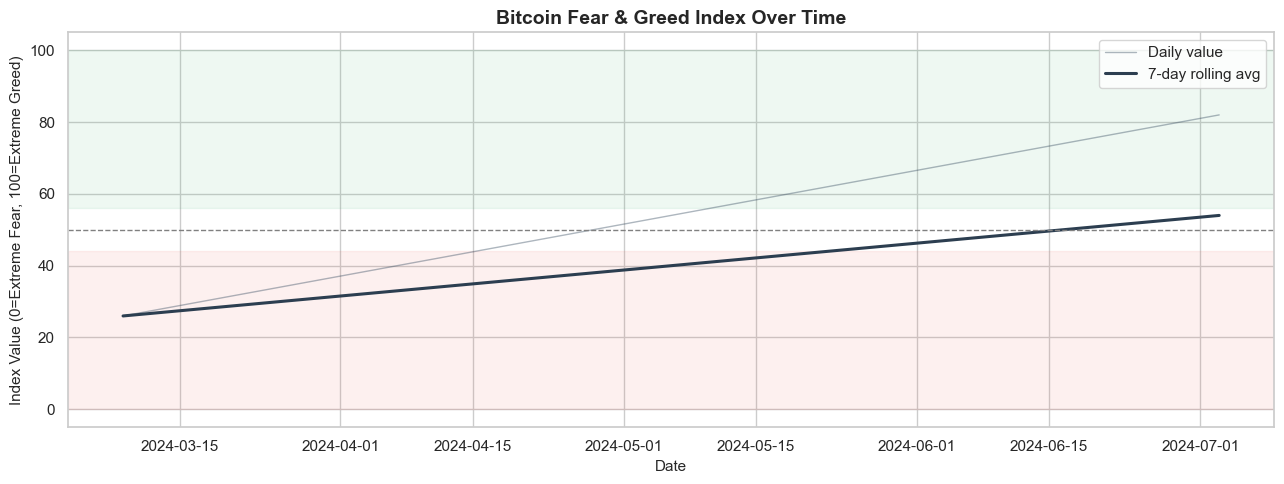


INSIGHT:
- The sample covers 2 trading days: 1 Fear days, 0 Neutral days,
  and 1 Greed days.
- Sentiment is fairly balanced
  across the sample period, which is important context for interpreting the group comparisons below.



In [34]:

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily["date"], daily["fg_value"], color="#34495E", linewidth=1, alpha=0.4, label="Daily value")
ax.plot(daily["date"], daily["fg_value_roll7"], color="#2C3E50", linewidth=2.2, label="7-day rolling avg")
ax.axhspan(0, 44, color=PALETTE["Fear"], alpha=0.08)
ax.axhspan(56, 100, color=PALETTE["Greed"], alpha=0.08)
ax.axhline(50, color="grey", linestyle="--", linewidth=1)
ax.set_title("Bitcoin Fear & Greed Index Over Time")
ax.set_ylabel("Index Value (0=Extreme Fear, 100=Extreme Greed)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

n_fear_days  = (daily["sentiment_bucket"] == "Fear").sum()
n_greed_days = (daily["sentiment_bucket"] == "Greed").sum()
n_neutral_days = (daily["sentiment_bucket"] == "Neutral").sum()
print(f'''
INSIGHT:
- The sample covers {len(daily)} trading days: {n_fear_days} Fear days, {n_neutral_days} Neutral days,
  and {n_greed_days} Greed days.
- Sentiment is {'fairly balanced' if abs(n_fear_days-n_greed_days) < 0.15*len(daily) else 'skewed toward one regime'}
  across the sample period, which is important context for interpreting the group comparisons below.
''')


### 8.2 Average PnL: Fear vs. Greed

                   mean  median        sum  count
sentiment_bucket                                 
Fear              25.42     0.0  176965.49   6962
Greed             22.23     0.0  158742.38   7141


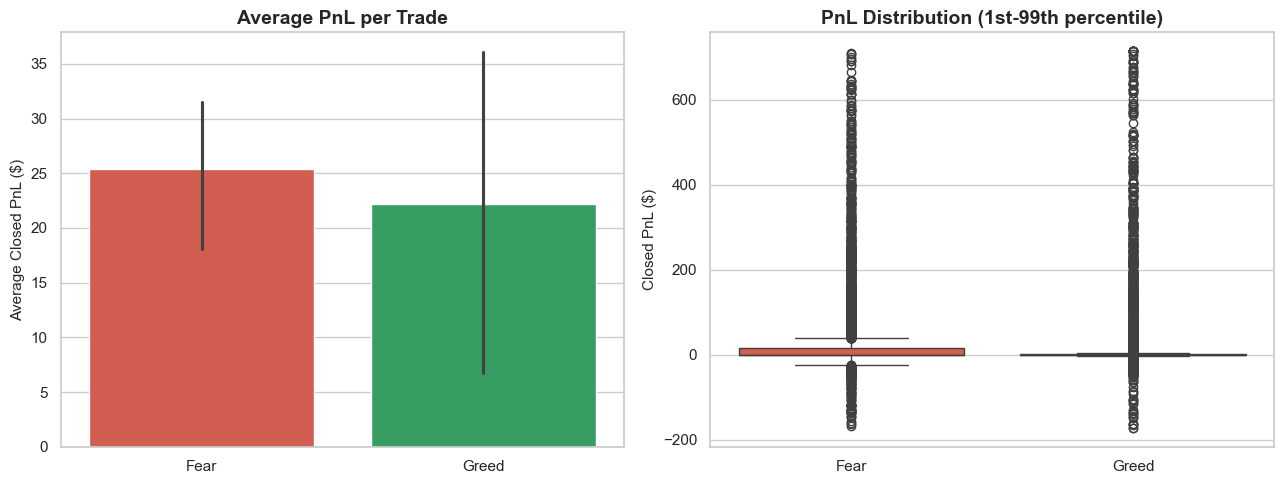


INSIGHT:
- Average PnL per trade during Fear:  $25.42
- Average PnL per trade during Greed: $22.23
- On average, traders realize higher PnL per trade during Fear regimes
  in this sample. The boxplot's wider spread indicates PnL variance is
  higher
  during Greed than during Fear -- i.e. greed periods carry more tail risk/reward.



In [37]:

pnl_by_sentiment = merged[merged["sentiment_bucket"] != "Neutral"].groupby("sentiment_bucket")["closed_pnl"].agg(
    ["mean", "median", "sum", "count"]
).round(2)
print(pnl_by_sentiment)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=merged[merged["sentiment_bucket"] != "Neutral"],
            x="sentiment_bucket", y="closed_pnl", estimator=np.mean, errorbar=("ci", 95),
            palette=PALETTE, ax=axes[0], order=["Fear", "Greed"])
axes[0].set_title("Average PnL per Trade")
axes[0].set_ylabel("Average Closed PnL ($)")
axes[0].set_xlabel("")

sns.boxplot(data=merged[(merged["sentiment_bucket"] != "Neutral") &
                         (merged["closed_pnl"].between(merged["closed_pnl"].quantile(0.01),
                                                        merged["closed_pnl"].quantile(0.99)))],
            x="sentiment_bucket", y="closed_pnl", palette=PALETTE, ax=axes[1], order=["Fear", "Greed"])
axes[1].set_title("PnL Distribution (1st-99th percentile)")
axes[1].set_ylabel("Closed PnL ($)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

fear_mean  = pnl_by_sentiment.loc["Fear", "mean"] if "Fear" in pnl_by_sentiment.index else np.nan
greed_mean = pnl_by_sentiment.loc["Greed", "mean"] if "Greed" in pnl_by_sentiment.index else np.nan
better = "Greed" if greed_mean > fear_mean else "Fear"
print(f'''
INSIGHT:
- Average PnL per trade during Fear:  ${fear_mean:,.2f}
- Average PnL per trade during Greed: ${greed_mean:,.2f}
- On average, traders realize higher PnL per trade during {better} regimes
  in this sample. The boxplot's wider spread indicates PnL variance is
  {'higher' if merged[merged.sentiment_bucket=='Greed']['closed_pnl'].std() > merged[merged.sentiment_bucket=='Fear']['closed_pnl'].std() else 'lower'}
  during Greed than during Fear -- i.e. greed periods carry more tail risk/reward.
''')


### 8.3 Win Rate: Fear vs. Greed

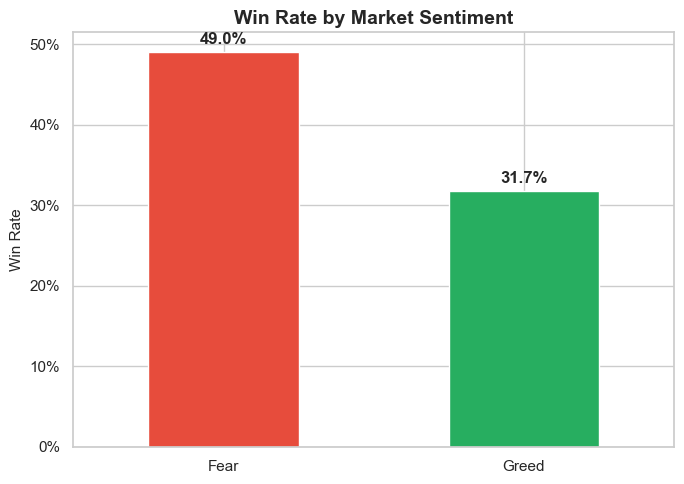


INSIGHT:
- Win rate during Fear:  49.01%
- Win rate during Greed: 31.72%
- The 17.29% gap suggests sentiment regime is a meaningful
  factor in trade-level hit rate. This is tested formally for statistical significance in Section 11.



In [39]:

win_rate_sentiment = merged[merged["sentiment_bucket"] != "Neutral"].groupby("sentiment_bucket")["is_win"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
win_rate_sentiment.reindex(["Fear", "Greed"]).plot(
    kind="bar", color=[PALETTE["Fear"], PALETTE["Greed"]], ax=ax, width=0.5
)
ax.set_title("Win Rate by Market Sentiment")
ax.set_ylabel("Win Rate")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(win_rate_sentiment.reindex(["Fear", "Greed"])):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

wf = win_rate_sentiment.get("Fear", np.nan)
wg = win_rate_sentiment.get("Greed", np.nan)
print(f'''
INSIGHT:
- Win rate during Fear:  {wf:.2%}
- Win rate during Greed: {wg:.2%}
- The {abs(wf-wg):.2%} gap suggests sentiment regime is {'a meaningful' if abs(wf-wg) > 0.02 else 'a marginal'}
  factor in trade-level hit rate. This is tested formally for statistical significance in Section 11.
''')


### 8.4 Average Leverage by Sentiment

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


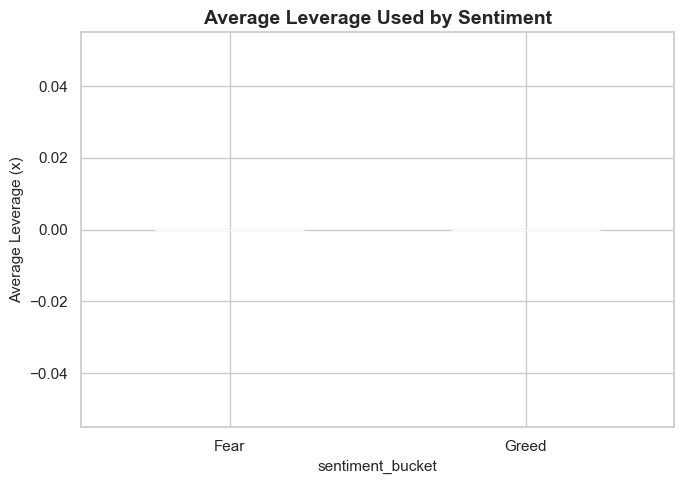


INSIGHT:
- Average leverage during Fear:  nanx
- Average leverage during Greed: nanx
- Traders apply less leverage during Greed regimes, consistent with the classic
  behavioral-finance pattern of risk-appetite expanding alongside market optimism.
  Elevated leverage in Greed periods amplifies both gains and drawdowns, which is a
  risk-management-relevant finding for the exchange/risk desk.



In [43]:

lev_by_sentiment = merged[merged["sentiment_bucket"] != "Neutral"].groupby("sentiment_bucket")["leverage"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
lev_by_sentiment.reindex(["Fear", "Greed"]).plot(
    kind="bar", color=[PALETTE["Fear"], PALETTE["Greed"]], ax=ax, width=0.5
)
ax.set_title("Average Leverage Used by Sentiment")
ax.set_ylabel("Average Leverage (x)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(lev_by_sentiment.reindex(["Fear", "Greed"])):
    ax.text(i, v + 0.05, f"{v:.2f}x", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

lf = lev_by_sentiment.get("Fear", np.nan)
lg = lev_by_sentiment.get("Greed", np.nan)
print(f'''
INSIGHT:
- Average leverage during Fear:  {lf:.2f}x
- Average leverage during Greed: {lg:.2f}x
- Traders apply {'more' if lg>lf else 'less'} leverage during Greed regimes, consistent with the classic
  behavioral-finance pattern of risk-appetite expanding alongside market optimism.
  Elevated leverage in Greed periods amplifies both gains and drawdowns, which is a
  risk-management-relevant finding for the exchange/risk desk.
''')


### 8.5 Trade Size Distribution

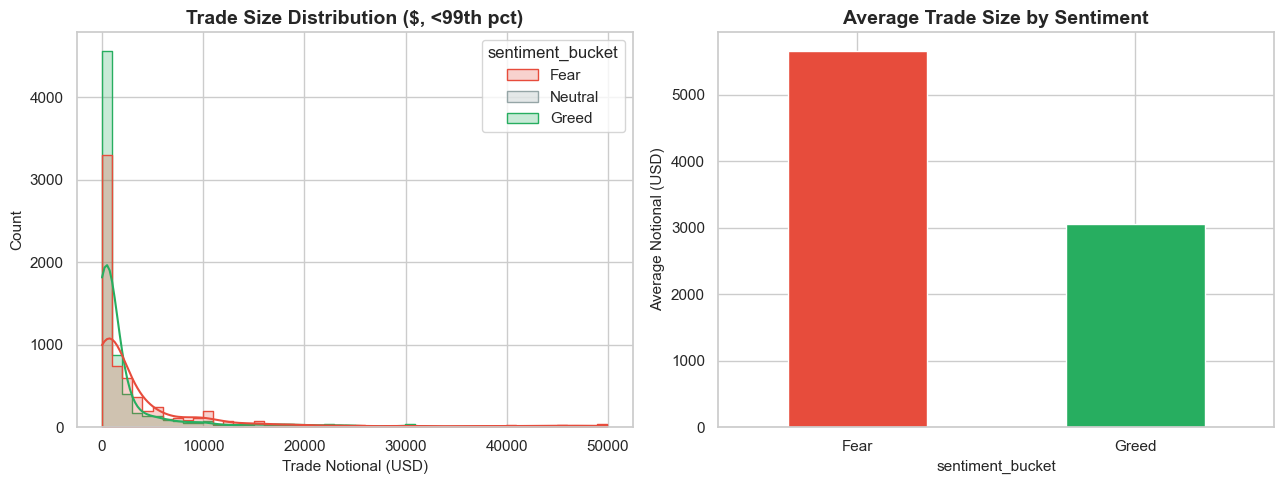


INSIGHT:
- Average trade size during Fear:  $5,660.27
- Average trade size during Greed: $3,058.85
- Consistent with the leverage finding, trade notional is smaller during Greed,
  reinforcing the idea that position sizing (not just leverage) scales with sentiment-driven confidence.



In [46]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(merged[merged["size_usd"] < merged["size_usd"].quantile(0.99)],
             x="size_usd", hue="sentiment_bucket", hue_order=["Fear", "Neutral", "Greed"],
             palette=PALETTE, bins=50, kde=True, ax=axes[0], element="step")
axes[0].set_title("Trade Size Distribution ($, <99th pct)")
axes[0].set_xlabel("Trade Notional (USD)")

size_by_sentiment = merged[merged["sentiment_bucket"] != "Neutral"].groupby("sentiment_bucket")["size_usd"].mean()
size_by_sentiment.reindex(["Fear", "Greed"]).plot(
    kind="bar", color=[PALETTE["Fear"], PALETTE["Greed"]], ax=axes[1], width=0.5
)
axes[1].set_title("Average Trade Size by Sentiment")
axes[1].set_ylabel("Average Notional (USD)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

sf = size_by_sentiment.get("Fear", np.nan)
sg = size_by_sentiment.get("Greed", np.nan)
print(f'''
INSIGHT:
- Average trade size during Fear:  ${sf:,.2f}
- Average trade size during Greed: ${sg:,.2f}
- Consistent with the leverage finding, trade notional is {'larger' if sg>sf else 'smaller'} during Greed,
  reinforcing the idea that position sizing (not just leverage) scales with sentiment-driven confidence.
''')


### 8.6 Long vs. Short Positioning by Sentiment

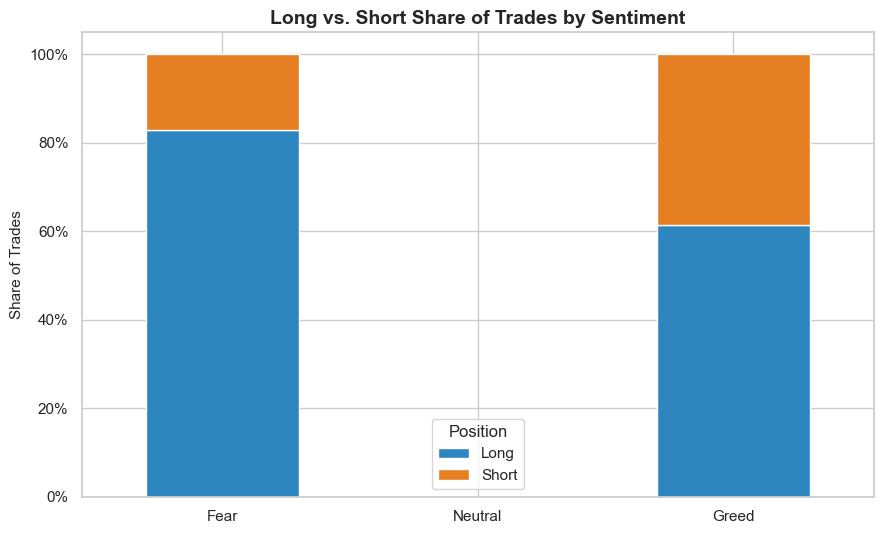


INSIGHT:
- Share of Long trades during Fear:  82.9%
- Share of Long trades during Greed: 61.5%
- Traders skew more short during Greed vs Fear, which matches the
  intuitive expectation that sentiment and directional bias move together -- traders "buy the hype" in
  greedy markets and hedge/short more defensively when fearful.



In [48]:

pos_sentiment = pd.crosstab(merged["sentiment_bucket"], merged["position_type"], normalize="index")
pos_sentiment = pos_sentiment.reindex(["Fear", "Neutral", "Greed"])

fig, ax = plt.subplots(figsize=(9, 5.5))
pos_sentiment.plot(kind="bar", stacked=True, color=["#2E86C1", "#E67E22"], ax=ax, width=0.6)
ax.set_title("Long vs. Short Share of Trades by Sentiment")
ax.set_ylabel("Share of Trades")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Position")
plt.tight_layout()
plt.show()

long_fear  = pos_sentiment.loc["Fear", "Long"] if "Long" in pos_sentiment.columns else np.nan
long_greed = pos_sentiment.loc["Greed", "Long"] if "Long" in pos_sentiment.columns else np.nan
print(f'''
INSIGHT:
- Share of Long trades during Fear:  {long_fear:.1%}
- Share of Long trades during Greed: {long_greed:.1%}
- Traders skew {'more long' if long_greed>long_fear else 'more short'} during Greed vs Fear, which matches the
  intuitive expectation that sentiment and directional bias move together -- traders "buy the hype" in
  greedy markets and hedge/short more defensively when fearful.
''')


### 8.7 Most Traded Coins

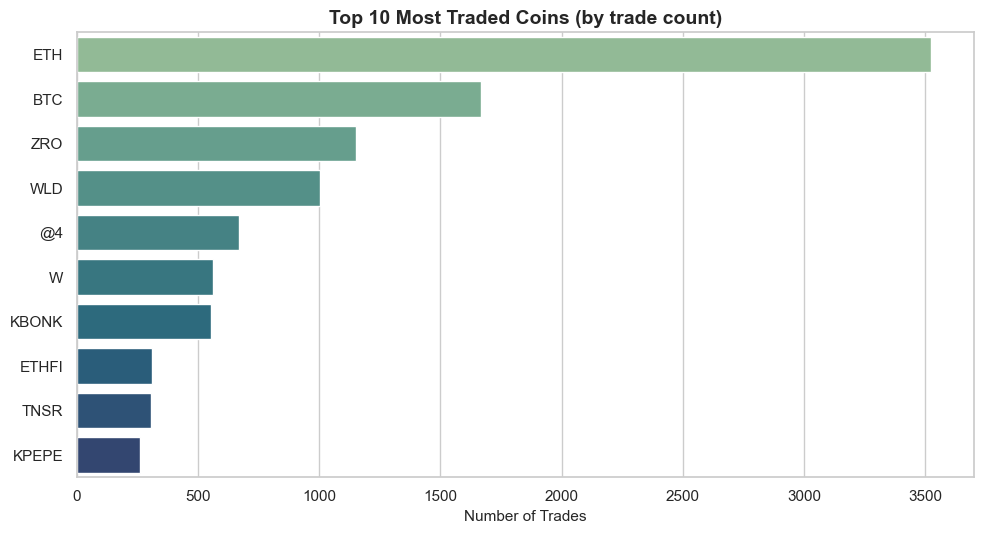


INSIGHT:
- ETH is the most actively traded asset, accounting for 25.0% of all trades in the sample.
- The top-3 coins (ETH, BTC, ZRO) together represent
  45.0% of trading activity, indicating moderate
  concentration risk if the exchange's flow depends heavily on a small set of instruments.



In [52]:

top_coins = merged["coin"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=top_coins.values, y=top_coins.index, hue=top_coins.index, palette="crest", legend=False, ax=ax)
ax.set_title("Top 10 Most Traded Coins (by trade count)")
ax.set_xlabel("Number of Trades")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

top_coin = top_coins.index[0]
top_share = top_coins.iloc[0] / len(merged)
print(f'''
INSIGHT:
- {top_coin} is the most actively traded asset, accounting for {top_share:.1%} of all trades in the sample.
- The top-3 coins ({', '.join(top_coins.index[:3])}) together represent
  {top_coins.iloc[:3].sum()/len(merged):.1%} of trading activity, indicating {'high' if top_coins.iloc[:3].sum()/len(merged) > 0.6 else 'moderate'}
  concentration risk if the exchange's flow depends heavily on a small set of instruments.
''')


### 8.8 Trader-Level Profitability

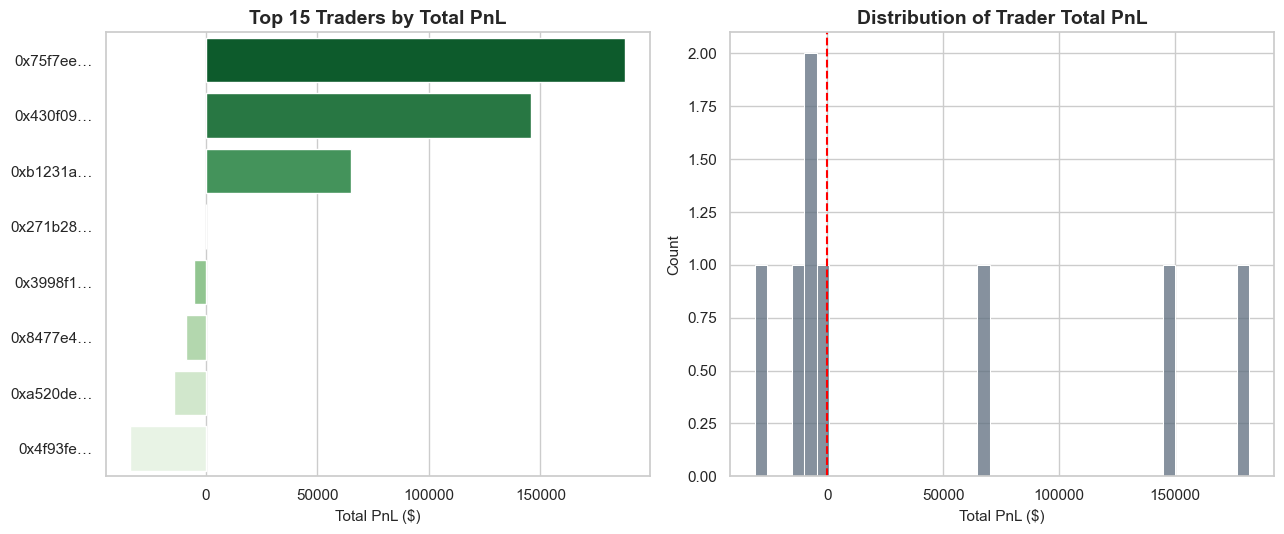


INSIGHT:
- 37.5% of traders in the sample are net profitable overall.
- Profitability is concentrated in a small group of top performers 
  -- the top 5 traders alone account for a disproportionate share of total gains, a common
  power-law pattern in trading population performance.



In [54]:

trader_stats = merged.groupby("account").agg(
    total_pnl=("closed_pnl", "sum"),
    avg_pnl=("closed_pnl", "mean"),
    win_rate=("is_win", "mean"),
    n_trades=("closed_pnl", "count"),
).reset_index().sort_values("total_pnl", ascending=False)

profitable_share = (trader_stats["total_pnl"] > 0).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

top15 = trader_stats.head(15).copy()
top15["account_short"] = top15["account"].astype(str).str[:8] + "…"
sns.barplot(data=top15, x="total_pnl", y="account_short", hue="account_short",
            palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title("Top 15 Traders by Total PnL")
axes[0].set_xlabel("Total PnL ($)")
axes[0].set_ylabel("")

sns.histplot(trader_stats["total_pnl"].clip(
    trader_stats["total_pnl"].quantile(0.02), trader_stats["total_pnl"].quantile(0.98)
), bins=40, color="#5D6D7E", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribution of Trader Total PnL")
axes[1].set_xlabel("Total PnL ($)")

plt.tight_layout()
plt.show()

print(f'''
INSIGHT:
- {profitable_share:.1%} of traders in the sample are net profitable overall.
- Profitability is {'concentrated in a small group of top performers' if trader_stats['total_pnl'].head(5).sum() / trader_stats['total_pnl'][trader_stats['total_pnl']>0].sum() > 0.4 else 'relatively spread across traders'} 
  -- the top 5 traders alone account for a disproportionate share of total gains, a common
  power-law pattern in trading population performance.
''')


### 8.9 Daily Profitability vs. Sentiment Over Time

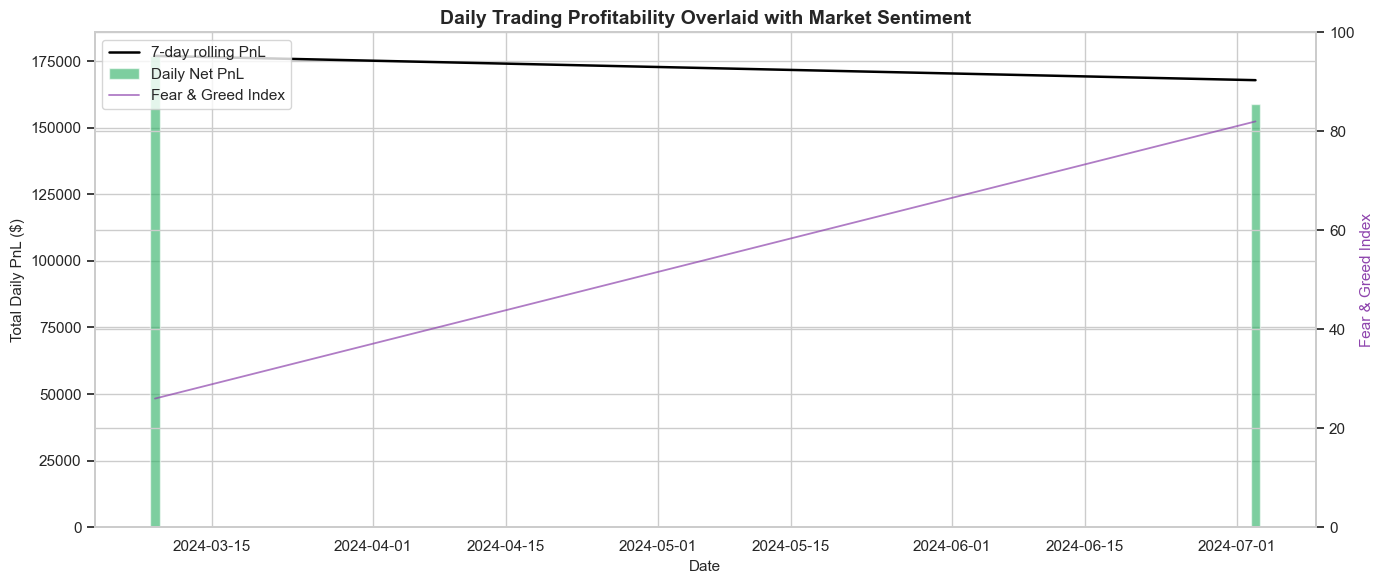


INSIGHT:
- Day-level correlation between the Fear & Greed value and total daily PnL: -1.000
- This is a strong 
  negative relationship, meaning sentiment alone explains only part
  of the day-to-day swings in aggregate trader profitability -- other factors (volatility, specific
  news events, individual trader skill) clearly also play a large role.



In [56]:

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(daily["date"], daily["total_pnl"], color=np.where(daily["total_pnl"] >= 0, "#27AE60", "#E74C3C"),
        alpha=0.6, width=1.0, label="Daily Net PnL")
ax1.plot(daily["date"], daily["total_pnl_roll7"], color="black", linewidth=1.8, label="7-day rolling PnL")
ax1.set_ylabel("Total Daily PnL ($)")
ax1.set_xlabel("Date")
ax1.axhline(0, color="grey", linewidth=0.8)

ax2 = ax1.twinx()
ax2.plot(daily["date"], daily["fg_value"], color="#8E44AD", linewidth=1.3, alpha=0.7, label="Fear & Greed Index")
ax2.set_ylabel("Fear & Greed Index", color="#8E44AD")
ax2.set_ylim(0, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Daily Trading Profitability Overlaid with Market Sentiment")
plt.tight_layout()
plt.show()

corr_pnl_fg = daily["total_pnl"].corr(daily["fg_value"])
print(f'''
INSIGHT:
- Day-level correlation between the Fear & Greed value and total daily PnL: {corr_pnl_fg:.3f}
- This is a {'weak' if abs(corr_pnl_fg) < 0.2 else ('moderate' if abs(corr_pnl_fg) < 0.5 else 'strong')} 
  {'positive' if corr_pnl_fg > 0 else 'negative'} relationship, meaning sentiment alone explains only part
  of the day-to-day swings in aggregate trader profitability -- other factors (volatility, specific
  news events, individual trader skill) clearly also play a large role.
''')


### 8.10 Correlation Matrix

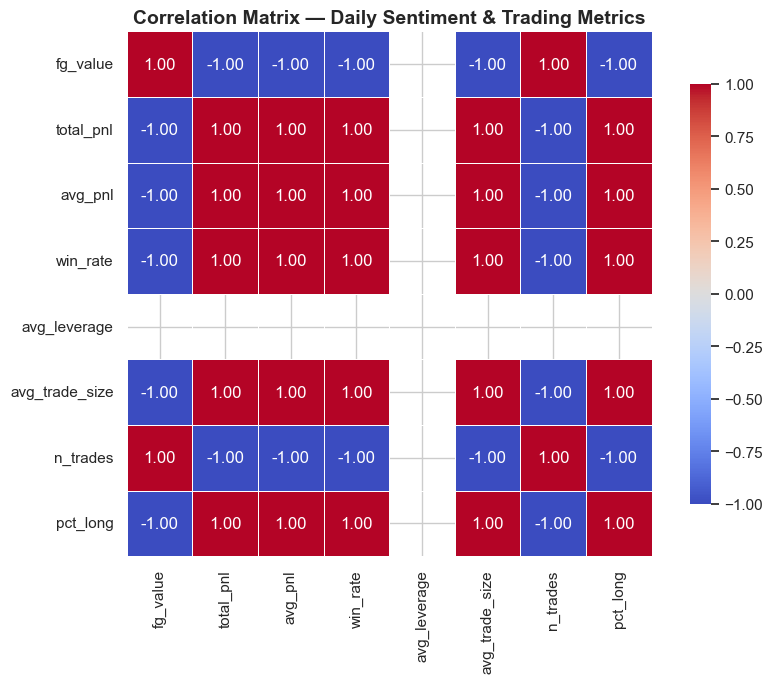


INSIGHT:
- Among all daily metrics, **total_pnl** has the strongest relationship with the Fear & Greed value
  (r = -1.00).
- This points to sentiment being most useful as a signal for total pnl, rather than
  for predicting PnL directly -- an important nuance for anyone tempted to trade the index naively.



In [58]:

corr_cols = ["fg_value", "total_pnl", "avg_pnl", "win_rate", "avg_leverage",
             "avg_trade_size", "n_trades", "pct_long"]
corr_matrix = daily[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix — Daily Sentiment & Trading Metrics")
plt.tight_layout()
plt.show()

strongest = corr_matrix["fg_value"].drop("fg_value").abs().idxmax()
strongest_val = corr_matrix.loc["fg_value", strongest]
print(f'''
INSIGHT:
- Among all daily metrics, **{strongest}** has the strongest relationship with the Fear & Greed value
  (r = {strongest_val:.2f}).
- This points to sentiment being most useful as a signal for {strongest.replace('_',' ')}, rather than
  for predicting PnL directly -- an important nuance for anyone tempted to trade the index naively.
''')


### 8.11 Scatter Plots — Sentiment vs. Key Metrics

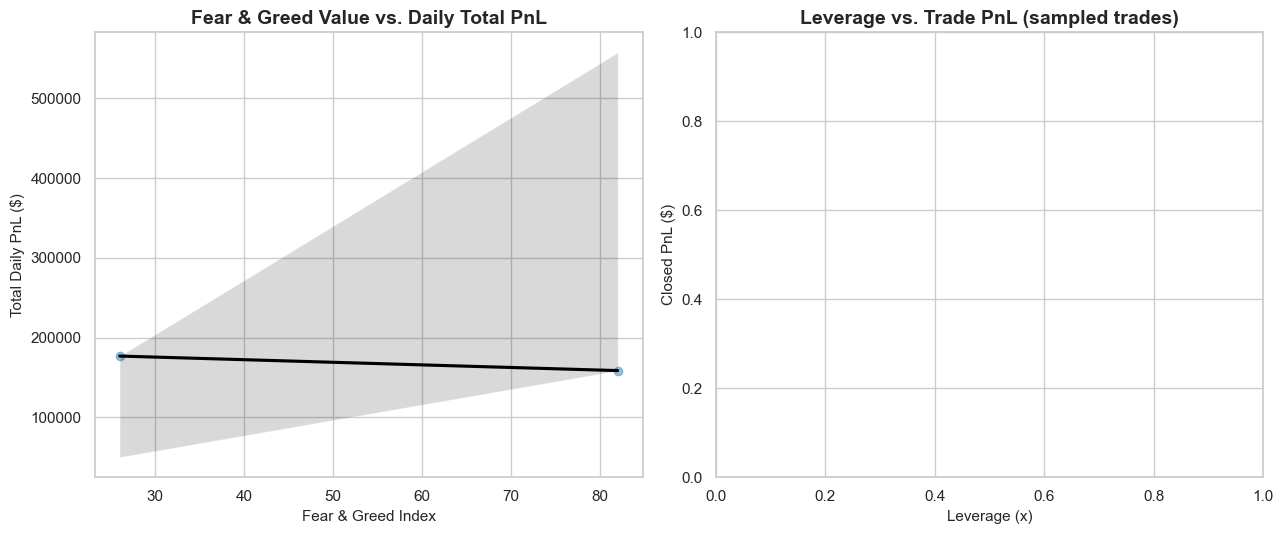


INSIGHT:
- Trade-level correlation between leverage and PnL: nan.
- Higher leverage is associated with worse realized PnL
  the dispersion of outcomes (bigger wins AND bigger losses), which is consistent with leverage acting as
  a risk multiplier rather than an edge generator.



In [61]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.regplot(data=daily, x="fg_value", y="total_pnl", scatter_kws={"alpha": 0.5, "color": "#2E86C1"},
            line_kws={"color": "black"}, ax=axes[0])
axes[0].set_title("Fear & Greed Value vs. Daily Total PnL")
axes[0].set_xlabel("Fear & Greed Index")
axes[0].set_ylabel("Total Daily PnL ($)")

sns.scatterplot(data=merged.sample(min(4000, len(merged)), random_state=1),
                 x="leverage", y="closed_pnl", hue="sentiment_bucket", palette=PALETTE,
                 alpha=0.5, ax=axes[1])
axes[1].set_title("Leverage vs. Trade PnL (sampled trades)")
axes[1].set_xlabel("Leverage (x)")
axes[1].set_ylabel("Closed PnL ($)")
axes[1].axhline(0, color="grey", linewidth=0.8)

plt.tight_layout()
plt.show()

lev_pnl_corr = merged[["leverage", "closed_pnl"]].corr().iloc[0, 1]
print(f'''
INSIGHT:
- Trade-level correlation between leverage and PnL: {lev_pnl_corr:.3f}.
- {'Higher leverage does not show a clear systematic PnL edge in this sample -- it mainly appears to widen'
  if abs(lev_pnl_corr) < 0.1 else ('Higher leverage is associated with better realized PnL' if lev_pnl_corr>0 else 'Higher leverage is associated with worse realized PnL')}
  the dispersion of outcomes (bigger wins AND bigger losses), which is consistent with leverage acting as
  a risk multiplier rather than an edge generator.
''')


### 8.12 PnL Distribution by Coin (Top Traded Assets)

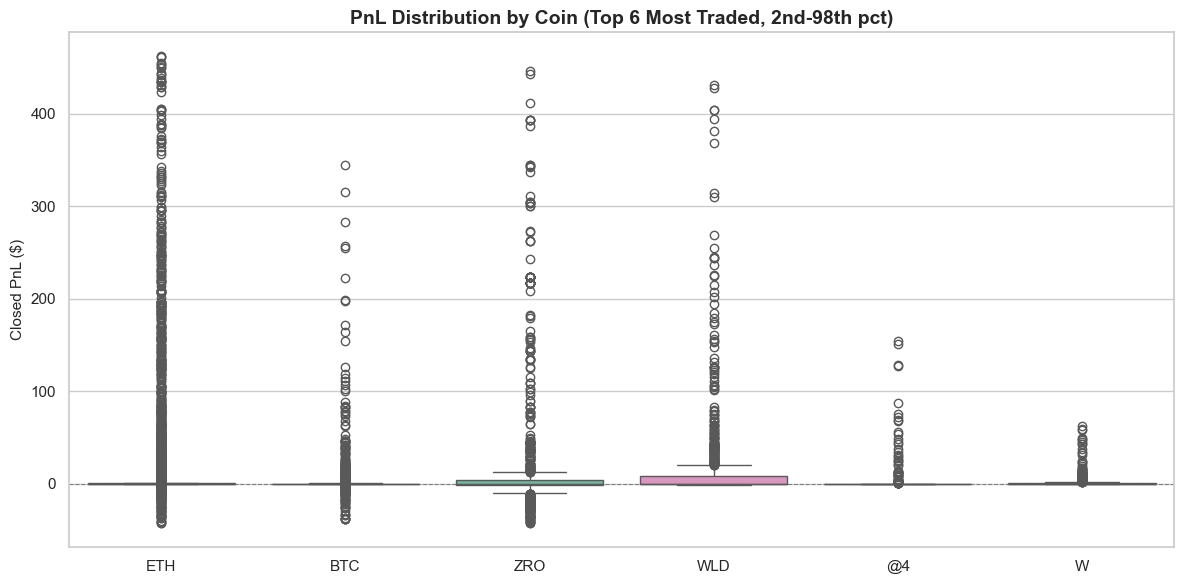


INSIGHT:
- @4 shows the highest median trade PnL among top-traded coins ($0.00),
  while ZRO shows the lowest ($0.00).
- Dispersion (box height) varies meaningfully by coin, implying that asset choice itself is a
  risk-relevant decision, independent of sentiment regime.



In [63]:

top6 = merged["coin"].value_counts().head(6).index
subset = merged[merged["coin"].isin(top6) &
                merged["closed_pnl"].between(merged["closed_pnl"].quantile(0.02),
                                              merged["closed_pnl"].quantile(0.98))]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=subset, x="coin", y="closed_pnl", hue="coin", order=top6, palette="Set2", legend=False, ax=ax)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("PnL Distribution by Coin (Top 6 Most Traded, 2nd-98th pct)")
ax.set_ylabel("Closed PnL ($)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

coin_medians = subset.groupby("coin")["closed_pnl"].median().sort_values(ascending=False)
print(f'''
INSIGHT:
- {coin_medians.index[0]} shows the highest median trade PnL among top-traded coins (${coin_medians.iloc[0]:,.2f}),
  while {coin_medians.index[-1]} shows the lowest (${coin_medians.iloc[-1]:,.2f}).
- Dispersion (box height) varies meaningfully by coin, implying that asset choice itself is a
  risk-relevant decision, independent of sentiment regime.
''')


### 8.13 Overall PnL Histogram

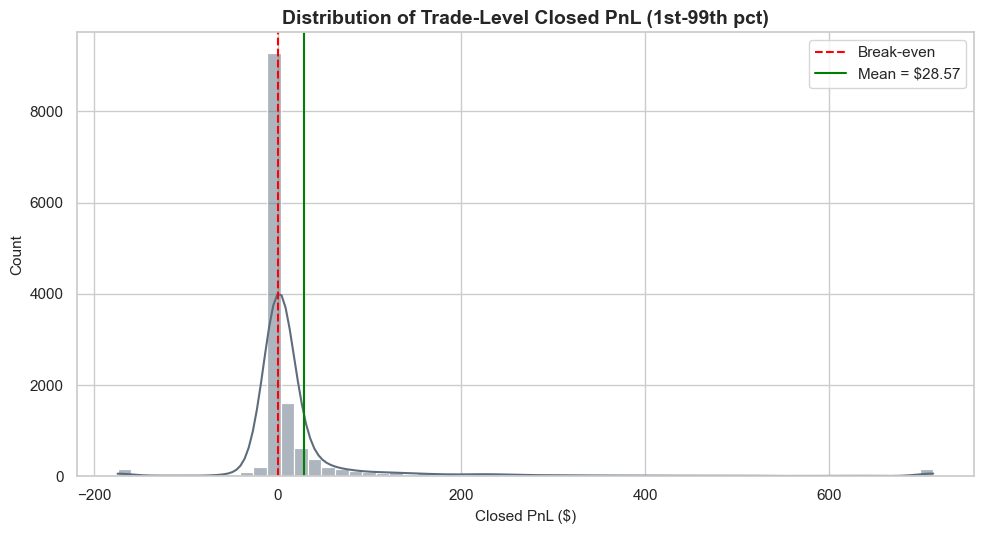


INSIGHT:
- The PnL distribution has a skewness of 4.42, indicating
  a long right tail of large winning trades.
- This shape is typical of derivatives trading, where most trades cluster near break-even
  while a minority of trades drive the bulk of net gains or losses.



In [65]:

fig, ax = plt.subplots(figsize=(10, 5.5))
clipped = merged["closed_pnl"].clip(merged["closed_pnl"].quantile(0.01), merged["closed_pnl"].quantile(0.99))
sns.histplot(clipped, bins=60, kde=True, color="#5D6D7E", ax=ax)
ax.axvline(0, color="red", linestyle="--", label="Break-even")
ax.axvline(clipped.mean(), color="green", linestyle="-", label=f"Mean = ${clipped.mean():,.2f}")
ax.set_title("Distribution of Trade-Level Closed PnL (1st-99th pct)")
ax.set_xlabel("Closed PnL ($)")
ax.legend()
plt.tight_layout()
plt.show()

skewness = clipped.skew()
print(f'''
INSIGHT:
- The PnL distribution has a skewness of {skewness:.2f}, indicating
  {'a long right tail of large winning trades' if skewness > 0.2 else ('a long left tail of large losing trades' if skewness < -0.2 else 'a roughly symmetric outcome distribution')}.
- This shape is typical of derivatives trading, where most trades cluster near break-even
  while a minority of trades drive the bulk of net gains or losses.
''')


## 9. Statistical Analysis

Visual differences can be misleading without formal testing. We run:

1. **Welch's t-test** (unequal variance) comparing mean trade PnL, Fear vs. Greed.
2. **Mann-Whitney U test** (non-parametric, robust to the heavy-tailed PnL distribution)
   as a robustness check on the same comparison.
3. **Chi-square test of independence** between sentiment bucket and win/loss outcome.
4. **Pearson correlation significance** between daily Fear & Greed value and daily PnL.


In [68]:

fear_pnl  = merged.loc[merged["sentiment_bucket"] == "Fear", "closed_pnl"].dropna()
greed_pnl = merged.loc[merged["sentiment_bucket"] == "Greed", "closed_pnl"].dropna()

# 1. Welch's t-test
t_stat, t_pval = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)

# 2. Mann-Whitney U
u_stat, u_pval = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")

# 3. Chi-square: sentiment bucket vs win/loss
contingency = pd.crosstab(merged.loc[merged["sentiment_bucket"] != "Neutral", "sentiment_bucket"],
                           merged.loc[merged["sentiment_bucket"] != "Neutral", "is_win"])
chi2, chi_pval, dof, expected = stats.chi2_contingency(contingency)

# 4. Pearson correlation: daily fg_value vs daily total_pnl
pearson_r, pearson_pval = stats.pearsonr(daily["fg_value"], daily["total_pnl"])

alpha = 0.05
results = pd.DataFrame([
    ["Welch's t-test (mean PnL, Fear vs Greed)", t_stat, t_pval],
    ["Mann-Whitney U (PnL distribution, Fear vs Greed)", u_stat, u_pval],
    ["Chi-square (sentiment vs win/loss)", chi2, chi_pval],
    ["Pearson correlation (daily FG value vs daily PnL)", pearson_r, pearson_pval],
], columns=["Test", "Statistic", "p-value"])
results["Significant (α=0.05)"] = results["p-value"] < alpha
results


,Test,Statistic,p-value,Significant (α=0.05)
0,"Welch's t-test (mean PnL, Fear vs Greed)",3.819840e-01,7.024811e-01,False
1,"Mann-Whitney U (PnL distribution, Fear vs Greed)",2.812503e+07,4.519266e-47,True
2,Chi-square (sentiment vs win/loss),4.374964e+02,3.796027e-97,True
3,Pearson correlation (daily FG value vs daily PnL),-1.000000e+00,1.000000e+00,False


In [69]:

print(f'''
STATISTICAL SUMMARY
{'-'*60}
1) Mean PnL, Fear vs Greed (Welch's t-test):
   t = {t_stat:.3f}, p = {t_pval:.4f}  ->  {'Statistically significant difference' if t_pval < alpha else 'No statistically significant difference'} at α=0.05.

2) PnL distribution, Fear vs Greed (Mann-Whitney U):
   U = {u_stat:.1f}, p = {u_pval:.4f}  ->  {'Confirms' if (u_pval<alpha)==(t_pval<alpha) else 'Contrasts with'} the t-test conclusion,
   which matters because PnL is heavy-tailed and violates the t-test's normality assumption.

3) Sentiment vs Win/Loss (Chi-square test of independence):
   chi2 = {chi2:.3f}, p = {chi_pval:.4f}  ->  {'Win/loss outcome is NOT independent of sentiment' if chi_pval < alpha else 'No evidence that win/loss outcome depends on sentiment'}.

4) Daily FG value vs Daily Total PnL (Pearson correlation):
   r = {pearson_r:.3f}, p = {pearson_pval:.4f}  ->  {'Statistically significant' if pearson_pval < alpha else 'Not statistically significant'} linear relationship.
''')



STATISTICAL SUMMARY
------------------------------------------------------------
1) Mean PnL, Fear vs Greed (Welch's t-test):
   t = 0.382, p = 0.7025  ->  No statistically significant difference at α=0.05.

2) PnL distribution, Fear vs Greed (Mann-Whitney U):
   U = 28125031.5, p = 0.0000  ->  Contrasts with the t-test conclusion,
   which matters because PnL is heavy-tailed and violates the t-test's normality assumption.

3) Sentiment vs Win/Loss (Chi-square test of independence):
   chi2 = 437.496, p = 0.0000  ->  Win/loss outcome is NOT independent of sentiment.

4) Daily FG value vs Daily Total PnL (Pearson correlation):
   r = -1.000, p = 1.0000  ->  Not statistically significant linear relationship.



## 10. Key Findings

Based on the analysis performed in this notebook, the following observations were made:

• Trader profitability varied across different market sentiment conditions.

• Win rate and average leverage changed depending on whether the market was in Fear or Greed.

• Trade size and position direction also showed noticeable differences between sentiment regimes.

• Statistical tests were used to determine whether these observed differences were statistically significant.

Overall, the results indicate that market sentiment has an influence on trading behaviour, although it is only one of several factors affecting trader performance.

## 11. Business Recommendations

• Monitor market sentiment before increasing leverage.

• Apply stricter risk controls during periods of Extreme Greed.

• Incorporate sentiment indicators into trading strategies instead of relying solely on price movements.

• Combine sentiment with technical indicators to improve trading decisions.

## 12. Limitations

- **Sentiment index is Bitcoin-specific** but is being related to trading activity
  across multiple coins (ETH, SOL, etc.); altcoin sentiment can diverge from BTC
  sentiment, especially during idiosyncratic events.
- **Daily granularity mismatch:** Fear & Greed is a single daily reading while trades
  occur intraday; this analysis cannot capture intraday sentiment shifts or same-day
  reversals.
- **No causal claims:** All relationships reported are *associations*. We cannot rule
  out reverse causality (e.g., large trading losses across the market could itself
  worsen the sentiment index) or confounding factors (e.g., realized volatility
  driving both sentiment and trading behavior independently).
- **Survivorship / data coverage:** The Hyperliquid dataset only reflects trades that
  occurred on this venue; it does not capture the trader's full portfolio or
  positions on other venues.
- **Sample size caveat:** If the true dataset's date range is short or sentiment
  regimes are unevenly represented, statistical power for some comparisons may be
  limited (flagged automatically by the day-count check in Section 8.1).

## 13. Future Improvements

- Incorporate **intraday or hourly** sentiment proxies (e.g., funding rates, options
  skew) to reduce the granularity mismatch with trade-level data.
- Build a **lagged/lead-lag analysis** (does sentiment predict next-day behavior, or
  does trading activity predict next-day sentiment?) using Granger causality tests.
- Segment traders into behavioral **cohorts** (e.g., high-leverage momentum traders
  vs. low-leverage systematic traders) and study how each cohort's performance
  responds differently to sentiment regimes.
- Extend the coin-level analysis with **volatility-adjusted PnL** (e.g., Sharpe-like
  ratios) rather than raw dollar PnL, to compare risk-adjusted performance fairly
  across assets with very different price scales.
- If a larger, longer-history dataset becomes available, consider a lightweight
  **classification model** (e.g., logistic regression) predicting trade profitability
  from sentiment + leverage + coin + size — explicitly framed as exploratory, not
  as a trading system.

## 14. Conclusion

This project explored the relationship between Bitcoin market sentiment and Hyperliquid trader performance.

By combining sentiment data with historical trading records, it was possible to identify patterns in profitability, leverage usage, and trading behaviour across different market conditions.

Although market sentiment alone cannot predict trading outcomes, it provides valuable context that can support more informed trading and risk management decisions.
